In [1]:
import os, shutil, time, random
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from io import BytesIO

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
COMBINED_DIR = './data/plants_combined'
SPECIES_SOURCE = '/content/drive/MyDrive/plants_species'

# Copy all species folders directly
if os.path.exists(COMBINED_DIR):
    shutil.rmtree(COMBINED_DIR)

shutil.copytree(SPECIES_SOURCE, COMBINED_DIR)

print('Done! Class counts:')
total = 0
for cls in sorted(os.listdir(COMBINED_DIR)):
    count = len(os.listdir(os.path.join(COMBINED_DIR, cls)))
    total += count
    print(f'  {cls}: {count} images')
print(f'Total: {total}')

Done! Class counts:
  Achillea_millefolium: 300 images
  Alliaria_petiolata: 300 images
  Arisaema_triphyllum: 300 images
  Dactylis_glomerata: 300 images
  Equisetum_arvense: 300 images
  Haddowia_longipes: 16 images
  Juniperus_virginiana: 300 images
  Maianthemum_racemosum: 300 images
  Onoclea_sensibilis: 300 images
  Phragmites_australis: 300 images
  Pinus_strobus: 300 images
  Pinus_sylvestris: 300 images
  Polystichum_acrostichoides: 300 images
  Pteridium_aquilinum: 300 images
  Trifolium_pratense: 300 images
  Trifolium_repens: 300 images
  Tsuga_canadensis: 300 images
Total: 4816


In [4]:
import shutil
shutil.rmtree('./data/plants_combined/Haddowia_longipes')
print('Removed Haddowia_longipes')

# Verify final counts
for cls in sorted(os.listdir('./data/plants_combined')):
    print(f'{cls}: {len(os.listdir(os.path.join("./data/plants_combined", cls)))}')

Removed Haddowia_longipes
Achillea_millefolium: 300
Alliaria_petiolata: 300
Arisaema_triphyllum: 300
Dactylis_glomerata: 300
Equisetum_arvense: 300
Juniperus_virginiana: 300
Maianthemum_racemosum: 300
Onoclea_sensibilis: 300
Phragmites_australis: 300
Pinus_strobus: 300
Pinus_sylvestris: 300
Polystichum_acrostichoides: 300
Pteridium_aquilinum: 300
Trifolium_pratense: 300
Trifolium_repens: 300
Tsuga_canadensis: 300


In [16]:
TAXON_IDS = {
    'Dactylis_glomerata': 52720,
    'Tsuga_canadensis': 48734,
}
TARGET = 500

for class_name, taxon_id in TAXON_IDS.items():
    folder = os.path.join(COMBINED_DIR, class_name)
    current = len(os.listdir(folder))
    needed = TARGET - current
    print(f'{class_name}: has {current}, fetching {needed} more...')
    fetched, page = 0, 1
    while fetched < needed and page <= 100:
        try:
            response = requests.get(
                'https://api.inaturalist.org/v1/observations',
                params={'taxon_id': taxon_id, 'quality_grade': 'research',
                        'photos': True, 'per_page': 100, 'page': page, 'order_by': 'id'},
                timeout=10
            )
            if response.status_code == 429:
                time.sleep(60)
                continue
            for obs in response.json().get('results', []):
                if fetched >= needed:
                    break
                try:
                    photo_url = obs['photos'][0]['url'].replace('square', 'medium')
                    img_data = requests.get(photo_url, timeout=10).content
                    img = Image.open(BytesIO(img_data)).convert('RGB')
                    count = len(os.listdir(folder))
                    img.save(os.path.join(folder, f'{count:05d}.jpg'))
                    fetched += 1
                except Exception:
                    continue
            page += 1
            time.sleep(1)
        except Exception:
            time.sleep(5)
            page += 1
    print(f'  Done! {class_name} now has {len(os.listdir(folder))} images')

Dactylis_glomerata: has 300, fetching 200 more...
  Done! Dactylis_glomerata now has 500 images
Tsuga_canadensis: has 300, fetching 200 more...
  Done! Tsuga_canadensis now has 500 images


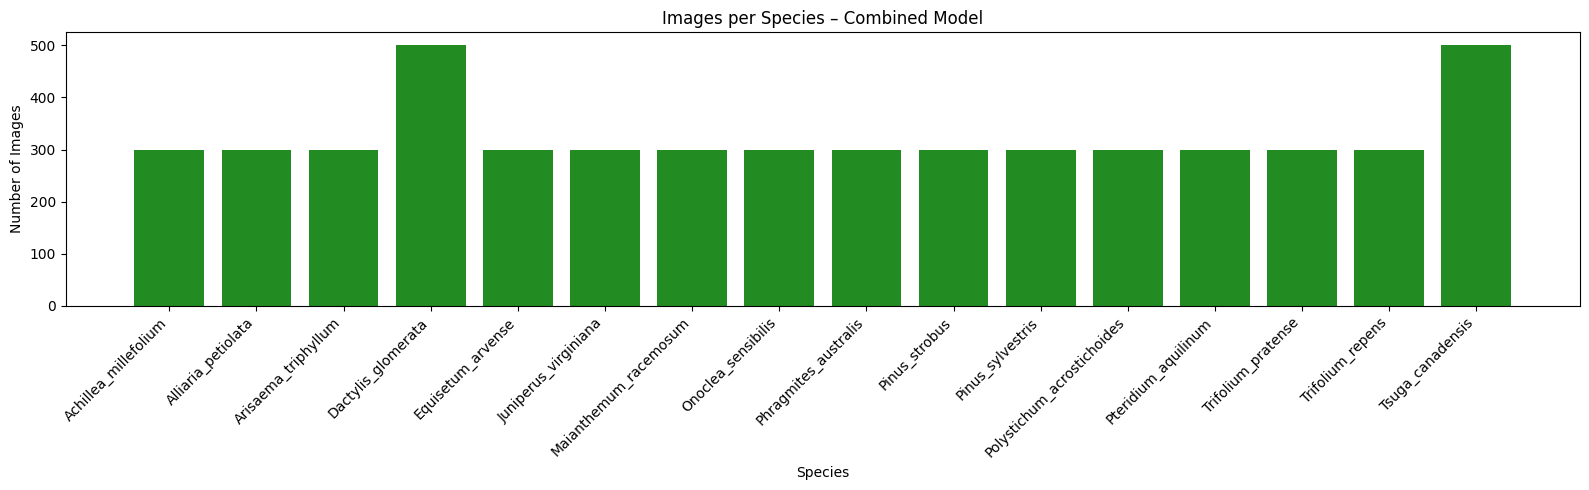

Total classes: 16
Total images: 5200


In [17]:
classes = sorted(os.listdir(COMBINED_DIR))
class_counts = {cls: len(os.listdir(os.path.join(COMBINED_DIR, cls))) for cls in classes}

plt.figure(figsize=(16, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='forestgreen')
plt.title('Images per Species – Combined Model')
plt.xlabel('Species')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(f'Total classes: {len(classes)}')
print(f'Total images: {sum(class_counts.values())}')

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_dataset = ImageFolder(root=COMBINED_DIR, transform=None)
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES = len(class_to_idx)
print(f'Total classes: {NUM_CLASSES}')
print(f'Total samples: {len(full_dataset)}')

total = len(full_dataset)
train_size = int(0.90 * total)
val_size   = int(0.05 * total)
test_size  = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Total classes: 16
Total samples: 5200
Train: 4680 | Val: 260 | Test: 260


In [19]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

BATCH_SIZE = 32
train_loader = DataLoader(TransformSubset(train_data, train_transforms),   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TransformSubset(val_data,   val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TransformSubset(test_data,  val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready!')

DataLoaders ready!


In [20]:
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

print(f'Model ready! Classes: {NUM_CLASSES}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Model ready! Classes: 16
Trainable params: 11,184,720


In [21]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


NUM_EPOCHS = 20
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0
best_model_path = 'best_plants_combined_model.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/20 | Train Loss: 1.2737 Acc: 0.6096 | Val Loss: 0.8207 Acc: 0.7269
Epoch 02/20 | Train Loss: 0.5746 Acc: 0.8209 | Val Loss: 0.6878 Acc: 0.7962
Epoch 03/20 | Train Loss: 0.3976 Acc: 0.8718 | Val Loss: 0.5950 Acc: 0.8038
Epoch 04/20 | Train Loss: 0.2833 Acc: 0.9156 | Val Loss: 0.5419 Acc: 0.8192
Epoch 05/20 | Train Loss: 0.2295 Acc: 0.9259 | Val Loss: 0.6171 Acc: 0.8077
Epoch 06/20 | Train Loss: 0.1765 Acc: 0.9485 | Val Loss: 0.6032 Acc: 0.8346
Epoch 07/20 | Train Loss: 0.1473 Acc: 0.9560 | Val Loss: 0.5517 Acc: 0.8423
Epoch 08/20 | Train Loss: 0.1131 Acc: 0.9665 | Val Loss: 0.5699 Acc: 0.8500
Epoch 09/20 | Train Loss: 0.0897 Acc: 0.9759 | Val Loss: 0.5363 Acc: 0.8654
Epoch 10/20 | Train Loss: 0.0608 Acc: 0.9853 | Val Loss: 0.5135 Acc: 0.8577
Epoch 11/20 | Train Loss: 0.0507 Acc: 0.9893 | Val Loss: 0.5102 Acc: 0.8538
Epoch 12/20 | Train Loss: 0.0454 Acc: 0.9925 | Val Loss: 0.5022 Acc: 0.8692
Epoch 13/20 | Train Loss: 0.0419 Acc: 0.9929 | Val Loss: 0.5273 Acc: 0.8577
Epoch 14/20 

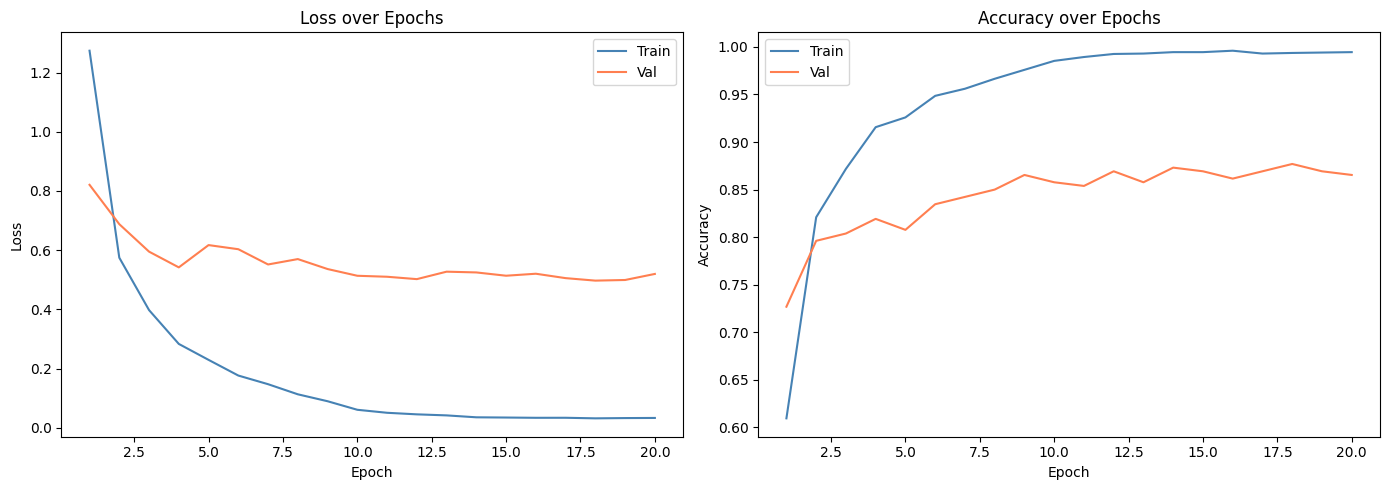

In [22]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train', color='steelblue')
ax1.plot(epochs, val_losses,   label='Val',   color='coral')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_accs, label='Train', color='steelblue')
ax2.plot(epochs, val_accs,   label='Val',   color='coral')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [23]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(all_labels, all_preds)
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
actual = cm.sum(axis=1)

print(f'General Accuracy: {(all_preds == all_labels).mean():.4f} ({(all_preds == all_labels).mean()*100:.2f}%)')
print()
print(f'{"Class":<30} {"TP":>6} {"FP":>6} {"Actual":>8} {"Precision":>10}')
print('-' * 65)
for i in range(len(cm)):
    precision = tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0
    print(f'{class_names[i]:<30} {tp[i]:>6} {fp[i]:>6} {actual[i]:>8} {precision:>10.4f}')

General Accuracy: 0.9000 (90.00%)

Class                              TP     FP   Actual  Precision
-----------------------------------------------------------------
Achillea_millefolium               14      0       15     1.0000
Alliaria_petiolata                 17      1       18     0.9444
Arisaema_triphyllum                18      1       19     0.9474
Dactylis_glomerata                 29      2       31     0.9355
Equisetum_arvense                  12      3       14     0.8000
Juniperus_virginiana                6      3        8     0.6667
Maianthemum_racemosum              12      0       14     1.0000
Onoclea_sensibilis                 19      1       21     0.9500
Phragmites_australis                7      3        8     0.7000
Pinus_strobus                      18      1       20     0.9474
Pinus_sylvestris                    9      2       11     0.8182
Polystichum_acrostichoides         12      0       14     1.0000
Pteridium_aquilinum                13      5       16 

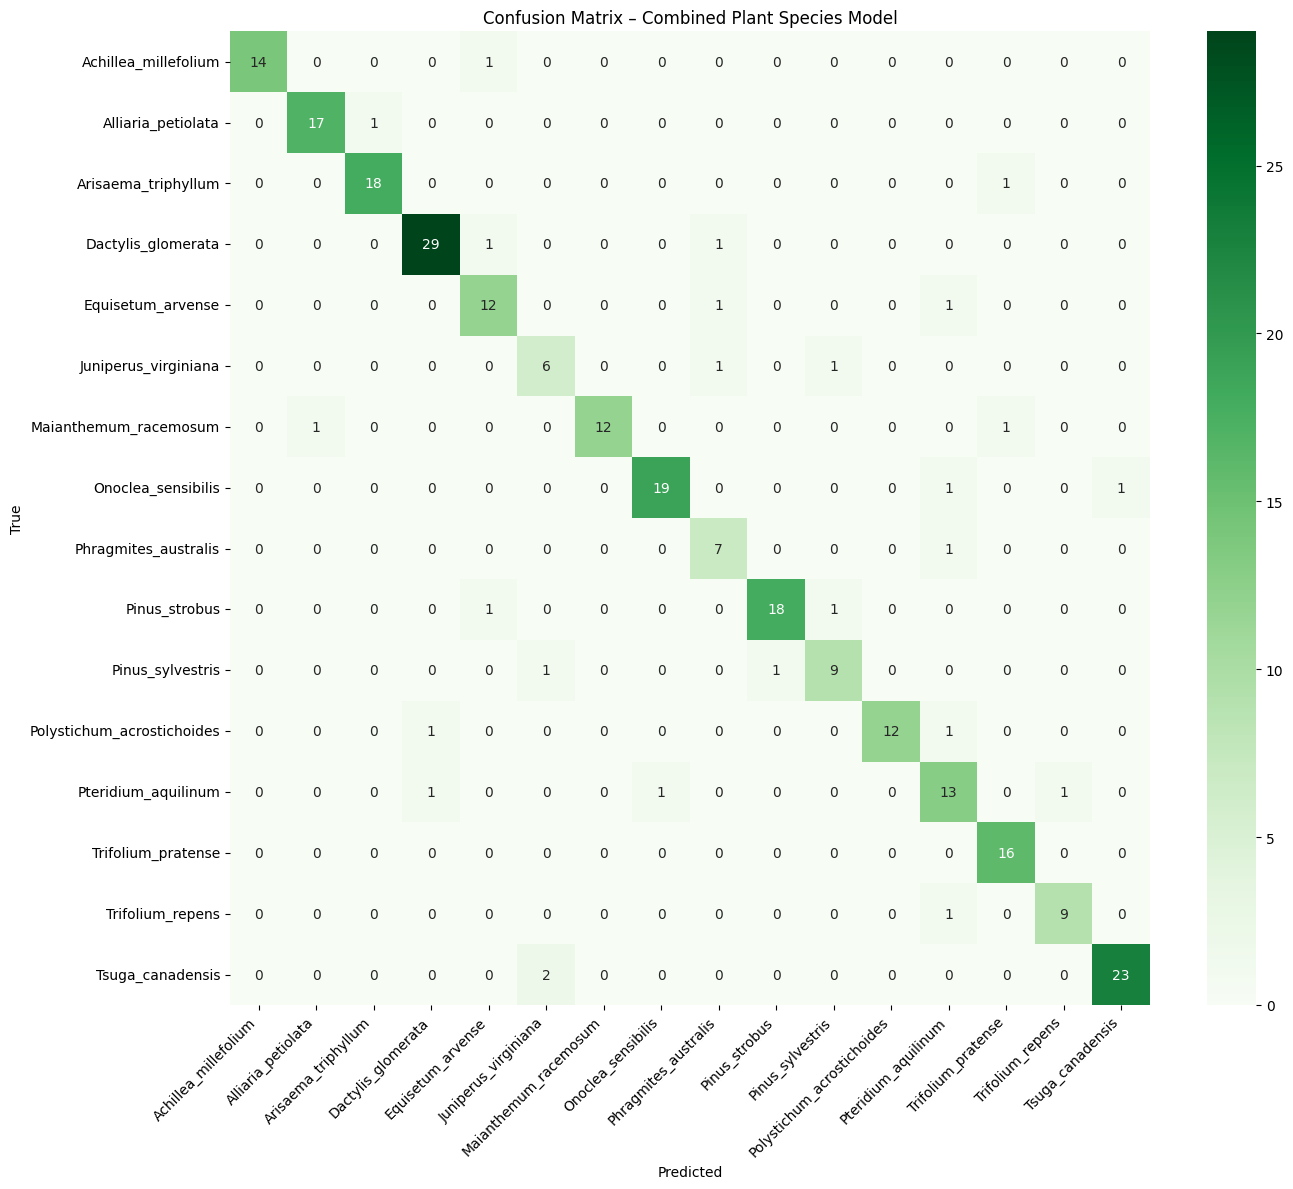

                            precision    recall  f1-score   support

      Achillea_millefolium       1.00      0.93      0.97        15
        Alliaria_petiolata       0.94      0.94      0.94        18
       Arisaema_triphyllum       0.95      0.95      0.95        19
        Dactylis_glomerata       0.94      0.94      0.94        31
         Equisetum_arvense       0.80      0.86      0.83        14
      Juniperus_virginiana       0.67      0.75      0.71         8
     Maianthemum_racemosum       1.00      0.86      0.92        14
        Onoclea_sensibilis       0.95      0.90      0.93        21
      Phragmites_australis       0.70      0.88      0.78         8
             Pinus_strobus       0.95      0.90      0.92        20
          Pinus_sylvestris       0.82      0.82      0.82        11
Polystichum_acrostichoides       1.00      0.86      0.92        14
       Pteridium_aquilinum       0.72      0.81      0.76        16
        Trifolium_pratense       0.89      1.00

In [24]:
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names[:len(cm)],
            yticklabels=class_names[:len(cm)], cmap='Greens')
plt.title('Confusion Matrix – Combined Plant Species Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names[:len(cm)]))

In [25]:
shutil.copy(best_model_path, '/content/drive/MyDrive/best_plants_combined_model.pth')
print('Model saved to Drive!')

Model saved to Drive!
